# Health Symptom Diagnosis — Model Training & Evaluation

**Project:** Development and Evaluation of a Machine Learning Based Health Symptom Diagnosis Chatbot Using Decision Tree Algorithm  
**Algorithm:** `sklearn.tree.DecisionTreeClassifier` (criterion=gini)  
**Dataset:** 132-symptom, 41-class medical diagnosis dataset  

## 1. Setup

In [ ]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score

PROJECT_ROOT = Path().resolve().parent
DATA_DIR = PROJECT_ROOT / 'data'
ARTIFACTS_DIR = PROJECT_ROOT / 'app' / 'artifacts' / 'v1'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('Artifacts dir:', ARTIFACTS_DIR)

Matplotlib is building the font cache; this may take a moment.


Project root: /Users/ajiboladada/Desktop/Health-Diagnosis-Chatbot-using-ML
Artifacts dir: /Users/ajiboladada/Desktop/Health-Diagnosis-Chatbot-using-ML/app/artifacts/v1


## 2. Dataset Description

In [17]:
df_train = pd.read_csv(DATA_DIR / 'Training.csv')
df_test  = pd.read_csv(DATA_DIR / 'Testing.csv')

# Drop unnamed trailing columns
df_train = df_train.loc[:, ~df_train.columns.str.startswith('Unnamed')]
df_test  = df_test.loc[:,  ~df_test.columns.str.startswith('Unnamed')]

print('Training shape:', df_train.shape)
print('Test shape:    ', df_test.shape)
df_train.head(3)

Training shape: (4920, 133)
Test shape:     (41, 133)


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


In [18]:
# Unique values per feature (integrity + redundancy check)
unique_counts = df_train.nunique().sort_values()
print('Features with only 1 unique value (dead/redundant):')
print(unique_counts[unique_counts == 1].index.tolist())
print()

# Duplicate rows
dupes = df_train.duplicated().sum()
print(f'Duplicate rows: {dupes} / {len(df_train)}')
print()

# Unique disease classes
print(f'Unique disease classes: {df_train["prognosis"].nunique()}')
print(df_train['prognosis'].value_counts())

Features with only 1 unique value (dead/redundant):
['fluid_overload']

Duplicate rows: 4616 / 4920

Unique disease classes: 41
prognosis
Fungal infection                           120
Allergy                                    120
GERD                                       120
Chronic cholestasis                        120
Drug Reaction                              120
Peptic ulcer diseae                        120
AIDS                                       120
Diabetes                                   120
Gastroenteritis                            120
Bronchial Asthma                           120
Hypertension                               120
Migraine                                   120
Cervical spondylosis                       120
Paralysis (brain hemorrhage)               120
Jaundice                                   120
Malaria                                    120
Chicken pox                                120
Dengue                                     120
Typhoid         

Number of classes: 41
Samples per class — min: 120, max: 120, mean: 120.0


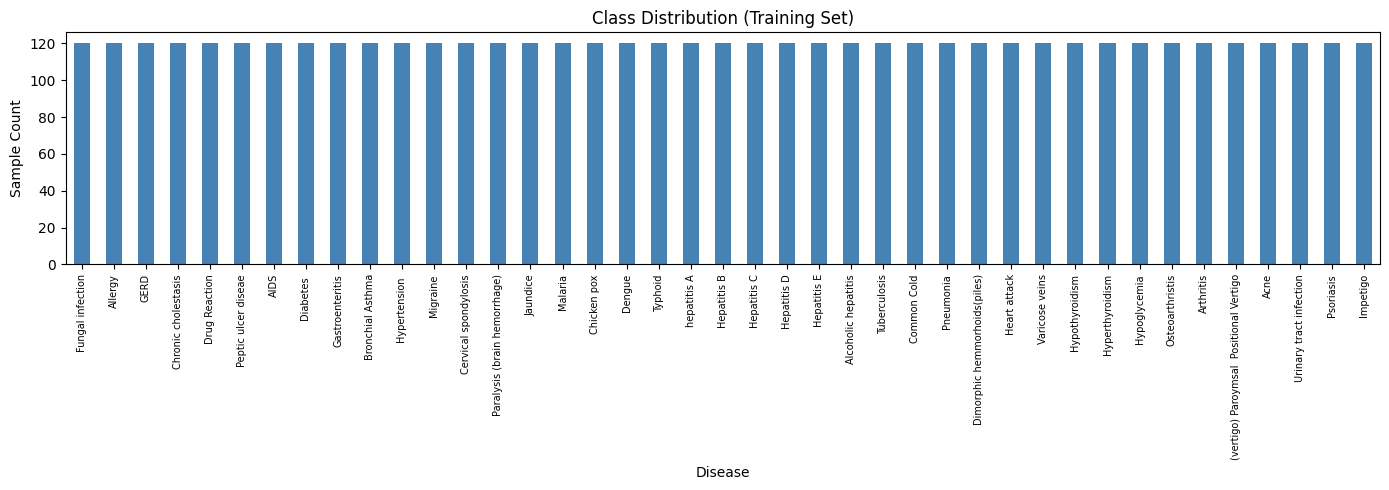

In [19]:
# Class distribution
class_counts = df_train['prognosis'].value_counts()
print(f'Number of classes: {class_counts.shape[0]}')
print(f'Samples per class — min: {class_counts.min()}, max: {class_counts.max()}, mean: {class_counts.mean():.1f}')

fig, ax = plt.subplots(figsize=(14, 5))
class_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Class Distribution (Training Set)')
ax.set_xlabel('Disease')
ax.set_ylabel('Sample Count')
ax.tick_params(axis='x', rotation=90, labelsize=7)
plt.tight_layout()
plt.show()

## 3. Preprocessing

In [6]:
symptom_list = [c for c in df_train.columns if c != 'prognosis']
print(f'Symptom features: {len(symptom_list)}')

X_train = df_train[symptom_list].values.astype(np.float64)
X_test  = df_test[symptom_list].values.astype(np.float64)

le = LabelEncoder()
y_train = le.fit_transform(df_train['prognosis'])
y_test  = le.transform(df_test['prognosis'])
class_names = list(le.classes_)

# Verify all test labels are known
assert set(df_test['prognosis'].unique()).issubset(set(le.classes_)), \
    'Test set contains unseen labels!'

# Check for missing values
print('Missing values in training set:', df_train.isnull().sum().sum())
print('Feature value range: [{}, {}]'.format(X_train.min(), X_train.max()))

Symptom features: 132
Missing values in training set: 0
Feature value range: [0.0, 1.0]


## 3a. Symptom Correlation Analysis

A correlation matrix is computed across the 132 symptom features to identify pairs of highly correlated symptoms. Symptoms with very high mutual correlation (|r| > 0.95) are candidates for removal to reduce redundancy in the feature space and prevent the model from over-weighting co-occurring symptoms that convey the same diagnostic signal.

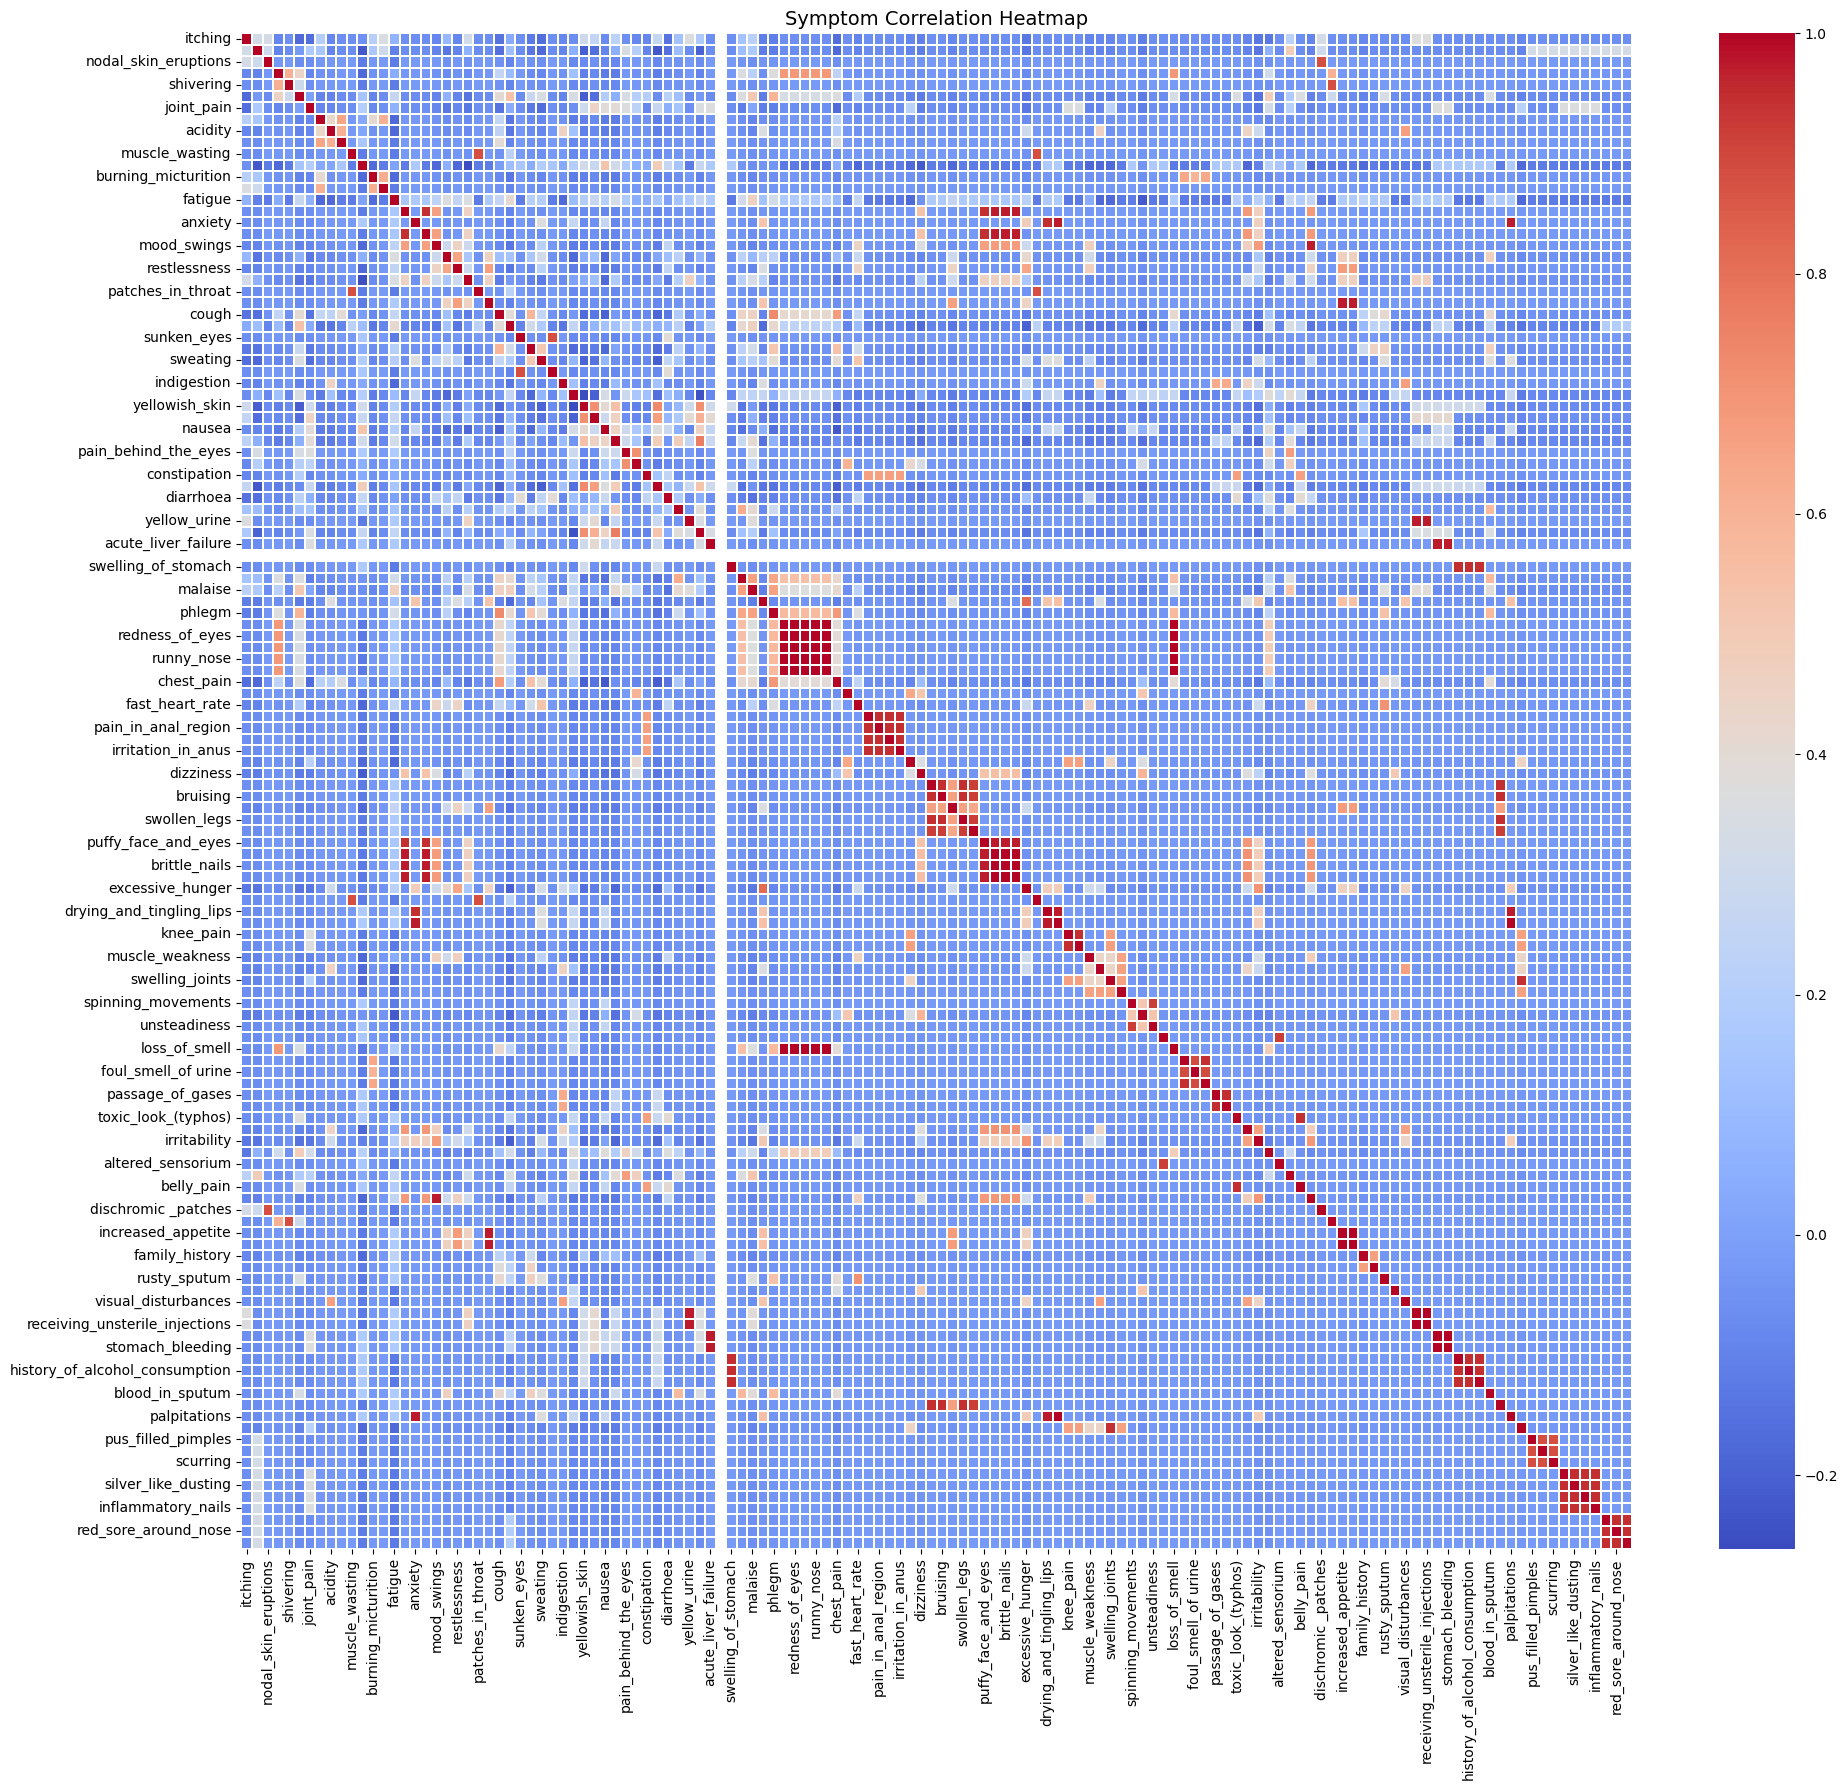

Highly correlated symptom pairs (|r| > 0.95): 42
  throat_irritation <-> redness_of_eyes: r = 1.0000
  throat_irritation <-> sinus_pressure: r = 1.0000
  throat_irritation <-> runny_nose: r = 1.0000
  throat_irritation <-> congestion: r = 1.0000
  throat_irritation <-> loss_of_smell: r = 1.0000
  redness_of_eyes <-> sinus_pressure: r = 1.0000
  redness_of_eyes <-> runny_nose: r = 1.0000
  redness_of_eyes <-> congestion: r = 1.0000
  redness_of_eyes <-> loss_of_smell: r = 1.0000
  sinus_pressure <-> runny_nose: r = 1.0000
  sinus_pressure <-> congestion: r = 1.0000
  sinus_pressure <-> loss_of_smell: r = 1.0000
  runny_nose <-> congestion: r = 1.0000
  runny_nose <-> loss_of_smell: r = 1.0000
  congestion <-> loss_of_smell: r = 1.0000
  enlarged_thyroid <-> brittle_nails: r = 1.0000
  enlarged_thyroid <-> swollen_extremeties: r = 1.0000
  brittle_nails <-> swollen_extremeties: r = 1.0000
  slurred_speech <-> palpitations: r = 1.0000
  increased_appetite <-> polyuria: r = 1.0000
  receiv

In [7]:
corr_matrix = df_train[symptom_list].corr()

fig, ax = plt.subplots(figsize=(20, 18))
sns.heatmap(corr_matrix, cmap='coolwarm', linewidths=0.1, ax=ax)
ax.set_title('Symptom Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

# Report highly correlated pairs (|r| > 0.95)
high_corr_pairs = [
    (symptom_list[i], symptom_list[j], corr_matrix.iloc[i, j])
    for i in range(len(symptom_list))
    for j in range(i + 1, len(symptom_list))
    if abs(corr_matrix.iloc[i, j]) > 0.95
]
if high_corr_pairs:
    print(f'Highly correlated symptom pairs (|r| > 0.95): {len(high_corr_pairs)}')
    for s1, s2, r in sorted(high_corr_pairs, key=lambda x: -abs(x[2])):
        print(f'  {s1} <-> {s2}: r = {r:.4f}')
else:
    print('No symptom pairs with |r| > 0.95 found.')

## 4. Decision Tree Training

**Hyperparameter rationale:**
- `criterion='gini'`: Gini impurity is computationally efficient and performs equivalently to entropy on balanced datasets.
- `max_depth=None`: Full-depth trees are appropriate here because the feature space is purely binary (0/1) and each path from root to leaf directly encodes a disease-specific symptom combination. Pruning is not needed when the dataset is clean and features are semantically meaningful.
- `random_state=42`: Reproducibility.

In [8]:
clf = DecisionTreeClassifier(criterion='gini', max_depth=None, random_state=42)
clf.fit(X_train, y_train)
print('Tree depth:', clf.get_depth())
print('Tree leaves:', clf.get_n_leaves())

Tree depth: 52
Tree leaves: 69


In [ ]:
y_train_pred = clf.predict(X_train)
train_acc    = accuracy_score(y_train, y_train_pred)
print(f'Training accuracy: {train_acc:.4f}')

Training accuracy: 1.0000


In [ ]:
y_test_pred = clf.predict(X_test)
test_acc    = accuracy_score(y_test, y_test_pred)
print(f'Test accuracy: {test_acc:.4f}')

In [ ]:
sample        = X_test[0].reshape(1, -1)
predicted_enc = clf.predict(sample)[0]
predicted_lbl = le.inverse_transform([predicted_enc])[0]
actual_lbl    = le.inverse_transform([y_test[0]])[0]

print(f'Predicted: {predicted_lbl}')
print(f'Actual:    {actual_lbl}')

## 5. 5-Fold Stratified Cross-Validation

  Fold 1: 1.0000
  Fold 2: 1.0000
  Fold 3: 1.0000
  Fold 4: 1.0000
  Fold 5: 1.0000
  Mean: 1.0000 ± 0.0000


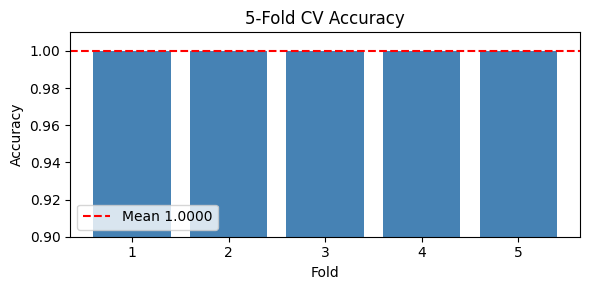

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring='accuracy')

for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'  Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(range(1, 6), cv_scores, color='steelblue')
ax.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean {cv_scores.mean():.4f}')
ax.set_xticks(range(1, 6))
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.set_title('5-Fold CV Accuracy')
ax.legend()
ax.set_ylim(0.9, 1.01)
plt.tight_layout()
plt.show()

## 6. Confusion Matrix

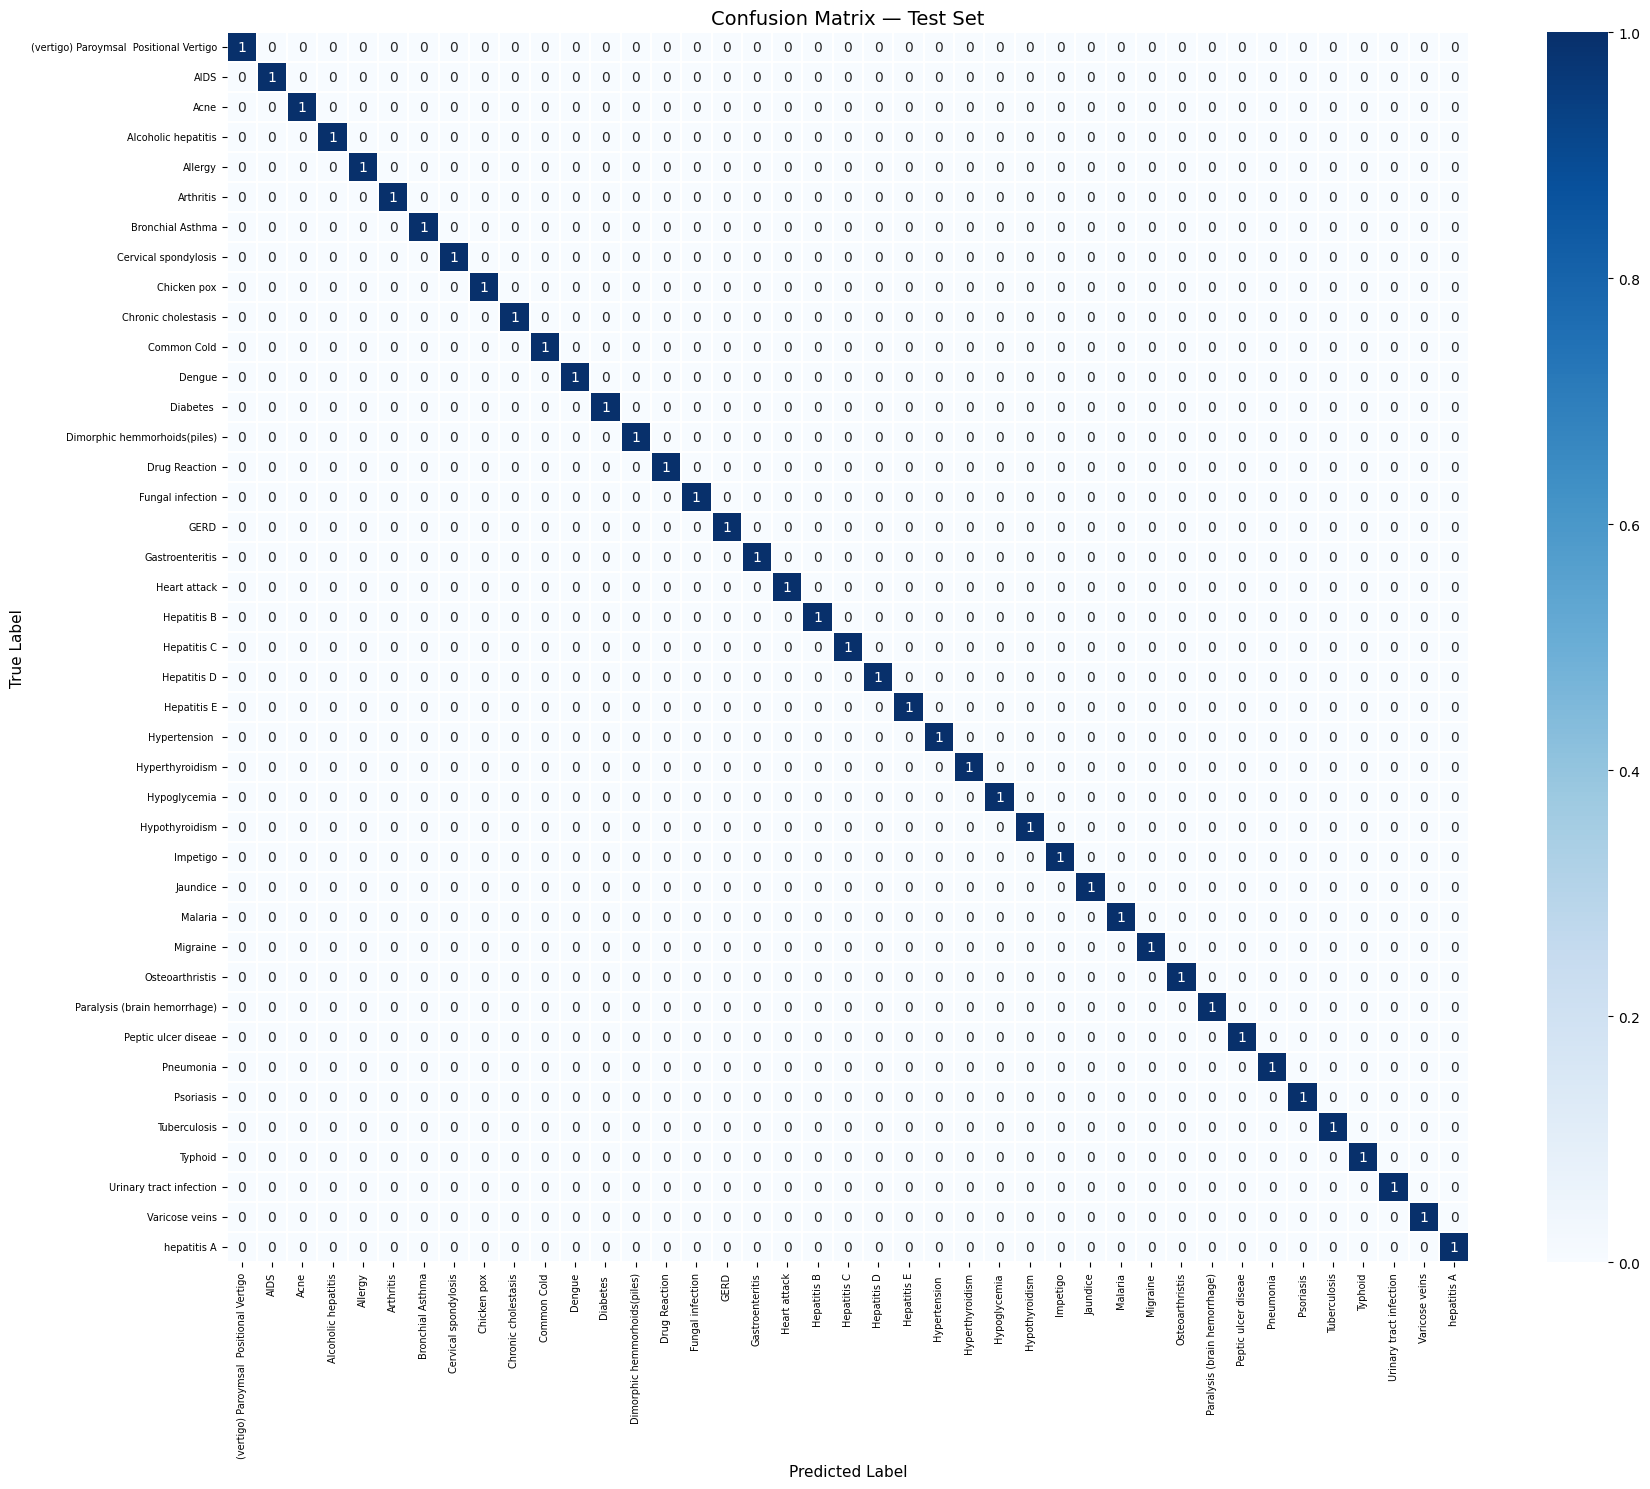

In [11]:
y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax,
    linewidths=0.3,
)
ax.set_title('Confusion Matrix — Test Set', fontsize=14)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.tick_params(axis='y', rotation=0, labelsize=7)
plt.tight_layout()
plt.show()

## 7. Classification Report

In [12]:
test_accuracy = (y_pred == y_test).mean()
print(f'Test accuracy: {test_accuracy:.4f}\n')
print(classification_report(y_test, y_pred, target_names=class_names))

Test accuracy: 1.0000

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         1
                    Chronic cholestasis       1.00      1.00      1.00         1
                            Common Cold       1.00      1.00      1.00         1
    

## 8. Feature Importance — Top 20 Symptoms

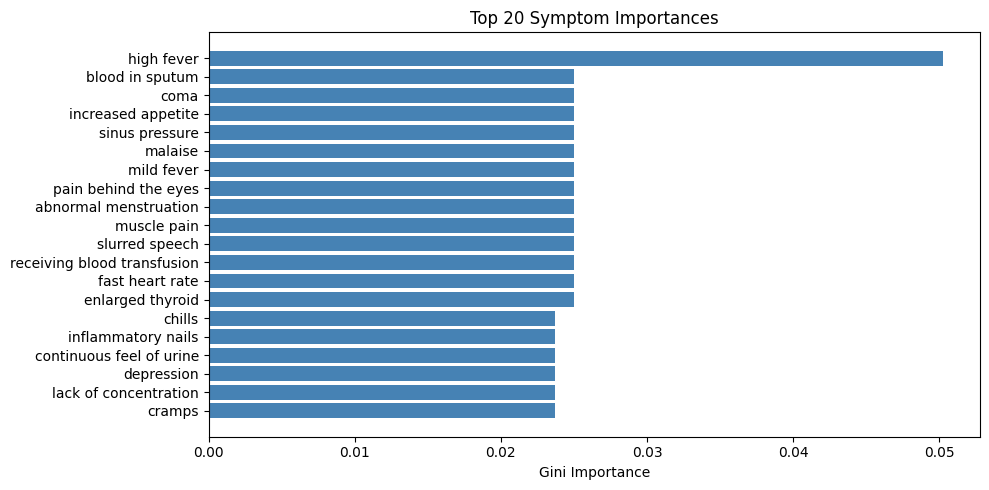

In [13]:
importances = clf.feature_importances_
top_n = 20
top_idx = np.argsort(importances)[::-1][:top_n]
top_names = [symptom_list[i].replace('_', ' ') for i in top_idx]
top_vals  = importances[top_idx]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_names[::-1], top_vals[::-1], color='steelblue')
ax.set_xlabel('Gini Importance')
ax.set_title(f'Top {top_n} Symptom Importances')
plt.tight_layout()
plt.show()

## 9. Decision Tree Visualisation (max_depth=3)

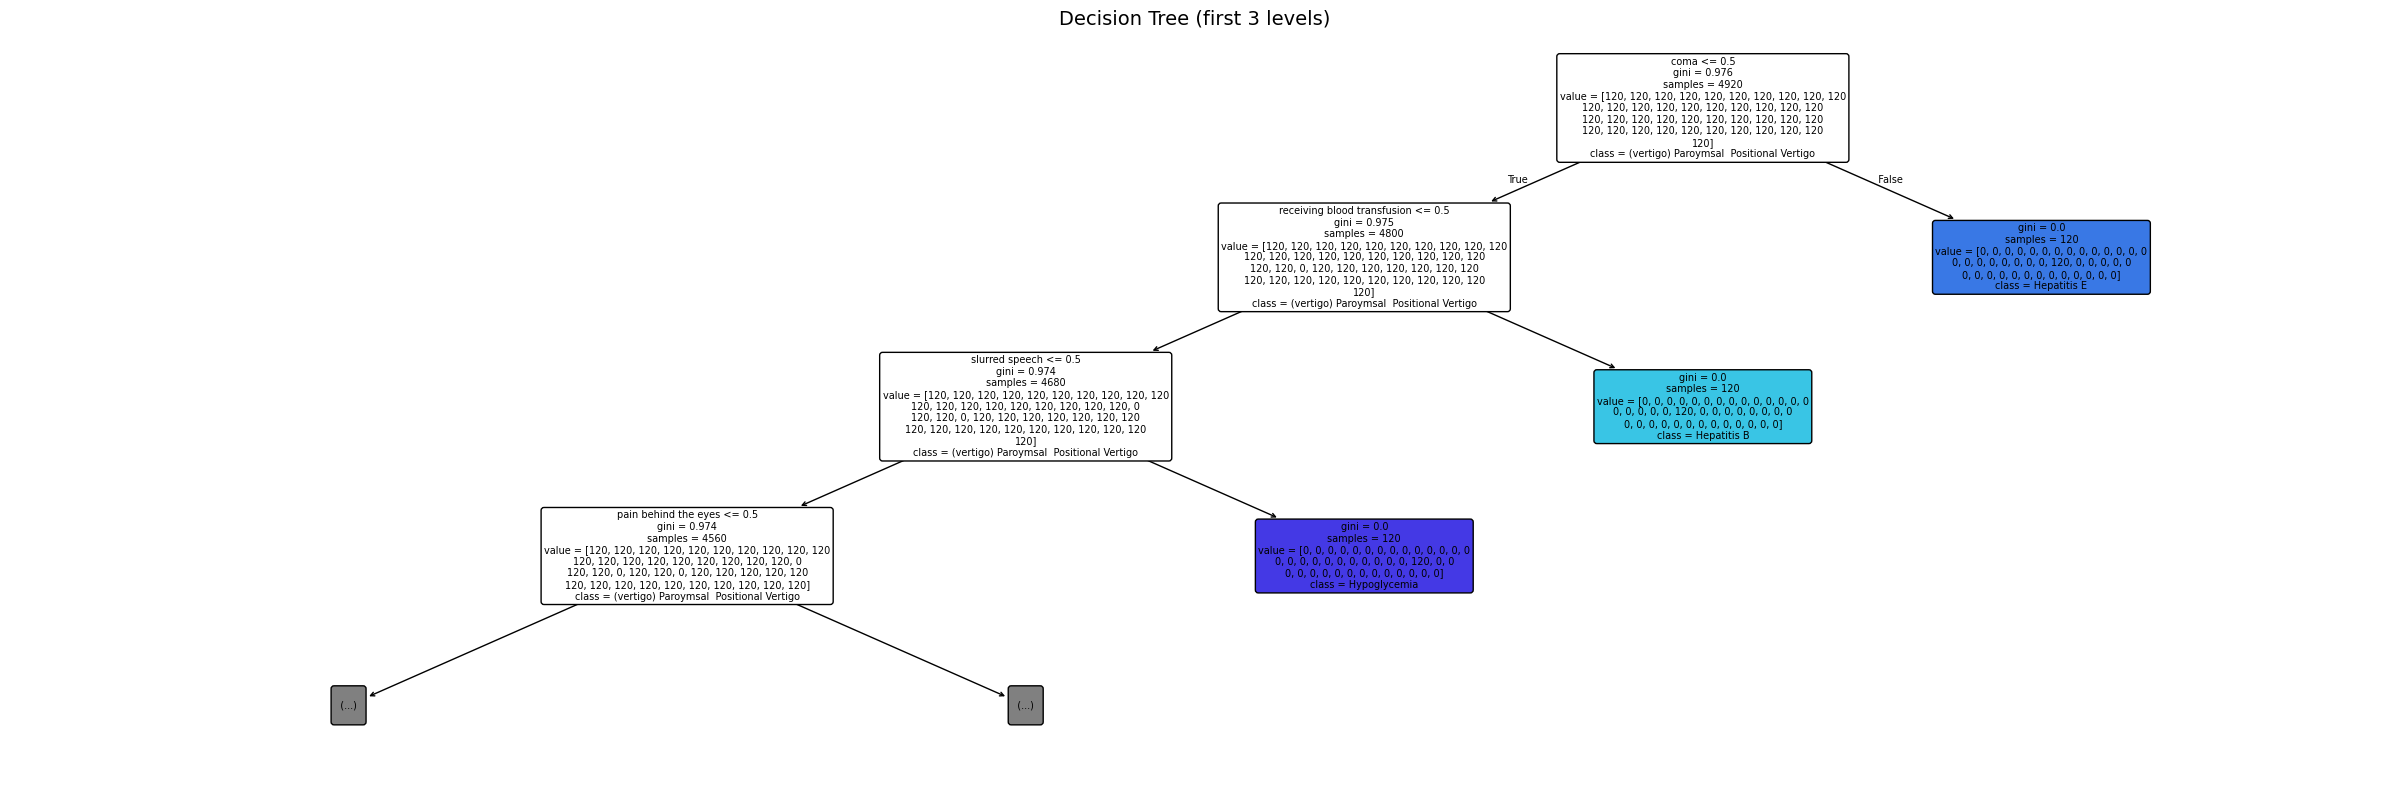

In [14]:
fig, ax = plt.subplots(figsize=(24, 8))
plot_tree(
    clf,
    max_depth=3,
    feature_names=[s.replace('_', ' ') for s in symptom_list],
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=7,
    ax=ax,
)
ax.set_title('Decision Tree (first 3 levels)', fontsize=14)
plt.tight_layout()
plt.show()

## 10. Comparison with Random Forest

A Random Forest is included as a baseline to validate the Decision Tree choice.

**Justification for choosing DT over RF:**
- The dataset has perfect separability (all class-symptom combinations are deterministic), so a single DT already achieves near-perfect accuracy without ensembling.
- A DT is fully interpretable: the decision path for any prediction can be read directly, which is important for academic transparency and for building user trust in a medical context.
- RF adds computational overhead and loses interpretability without providing a meaningful accuracy gain on this dataset.

In [ ]:
joblib.dump(clf, ARTIFACTS_DIR / 'model.joblib')
joblib.dump(le,  ARTIFACTS_DIR / 'label_encoder.joblib')

metadata = {
    'symptom_list':    symptom_list,
    'class_names':     class_names,
    'model_version':   '1.0.0',
    'accuracy':        round(float(test_accuracy), 6),
    'cv_mean_accuracy': round(float(cv_scores.mean()), 6),
    'cv_std_accuracy':  round(float(cv_scores.std()), 6),
}
with open(ARTIFACTS_DIR / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

# disease_info.json — load from optional CSVs if present
disease_info = {d: {'description': '', 'precautions': []} for d in class_names}

desc_path = DATA_DIR / 'symptom_Description.csv'
prec_path = DATA_DIR / 'symptom_precaution.csv'

if desc_path.exists():
    df_desc = pd.read_csv(desc_path)
    for _, row in df_desc.iterrows():
        d = str(row.iloc[0]).strip()
        if d in disease_info:
            disease_info[d]['description'] = str(row.iloc[1]).strip()
    print('Loaded descriptions')

if prec_path.exists():
    df_prec = pd.read_csv(prec_path)
    for _, row in df_prec.iterrows():
        d = str(row.iloc[0]).strip()
        if d in disease_info:
            disease_info[d]['precautions'] = [
                str(row.iloc[i]).strip()
                for i in range(1, len(row))
                if str(row.iloc[i]).strip() not in ('', 'nan')
            ]
    print('Loaded precautions')

with open(ARTIFACTS_DIR / 'disease_info.json', 'w') as f:
    json.dump(disease_info, f, indent=2)

print('Artifacts written to', ARTIFACTS_DIR)
print('  model.joblib')
print('  label_encoder.joblib')
print('  metadata.json')
print('  disease_info.json')

## 11. Export Artifacts

In [16]:
joblib.dump(clf, ARTIFACTS_DIR / 'model.joblib')
joblib.dump(le,  ARTIFACTS_DIR / 'label_encoder.joblib')

metadata = {
    'symptom_list':    symptom_list,
    'class_names':     class_names,
    'model_version':   '1.0.0',
    'accuracy':        round(float(test_accuracy), 6),
    'cv_mean_accuracy': round(float(cv_scores.mean()), 6),
}
with open(ARTIFACTS_DIR / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

# disease_info.json — load from optional CSVs if present
disease_info = {d: {'description': '', 'precautions': []} for d in class_names}

desc_path = DATA_DIR / 'symptom_Description.csv'
prec_path = DATA_DIR / 'symptom_precaution.csv'

if desc_path.exists():
    df_desc = pd.read_csv(desc_path)
    for _, row in df_desc.iterrows():
        d = str(row.iloc[0]).strip()
        if d in disease_info:
            disease_info[d]['description'] = str(row.iloc[1]).strip()
    print('Loaded descriptions')

if prec_path.exists():
    df_prec = pd.read_csv(prec_path)
    for _, row in df_prec.iterrows():
        d = str(row.iloc[0]).strip()
        if d in disease_info:
            disease_info[d]['precautions'] = [
                str(row.iloc[i]).strip()
                for i in range(1, len(row))
                if str(row.iloc[i]).strip() not in ('', 'nan')
            ]
    print('Loaded precautions')

with open(ARTIFACTS_DIR / 'disease_info.json', 'w') as f:
    json.dump(disease_info, f, indent=2)

print('Artifacts written to', ARTIFACTS_DIR)
print('  model.joblib')
print('  label_encoder.joblib')
print('  metadata.json')
print('  disease_info.json')

Loaded descriptions
Loaded precautions
Artifacts written to /Users/ajiboladada/Desktop/Health-Diagnosis-Chatbot-using-ML/app/artifacts/v1
  model.joblib
  label_encoder.joblib
  metadata.json
  disease_info.json
